# Altimetry time series for Terschelling

## Paths and settings

In [1]:
# paths jupyter utwente
path_input_general = '/home/jovyan/data/98_paper2_kf_dtm/0_input_general/'
path_input = '/home/jovyan/data/98_paper2_kf_dtm/11_Ters_altimetry/input/'
path_output = '/home/jovyan/data/98_paper2_kf_dtm/11_Ters_altimetry/output/'

In [2]:
epsg_in = 4326
epsg_out = 28992 # 32631 28992
overwrite = False # True: overwrite existing files, False: do not overwrite

## Imports

In [23]:
%load_ext autoreload
%autoreload 2

import os
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats
    
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.feature import LAND

from coastal_data import CD_helper_functions, CD_altimetry, CD_data_preparation, CD_statistics

import pdb

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data

### IB correction

In [4]:
overwrite = False
fn = 'ib_correction_era5.nc'
if (not os.path.isfile(path_input_general+fn)) | overwrite:
    corr = CD_altimetry.compute_ib_corr(path_input_general)

ibcorr = xr.open_dataset(path_input_general + fn)

Text(0.5, 1.0, 'IB correction in [m]')

<Figure size 2000x1000 with 0 Axes>

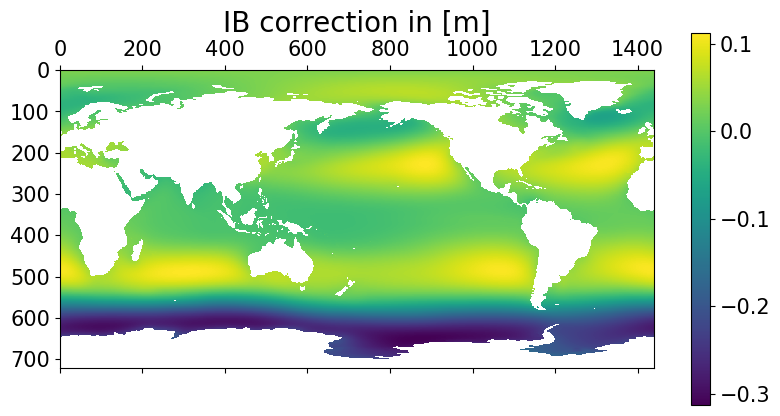

In [5]:
plt.figure(1, figsize=(20,10))
plt.matshow(ibcorr.mean('time').IB_correction)
plt.colorbar()
plt.title('IB correction in [m]')

masked array to xarray, fill value 0, but land areas filled with -20.000  
in the old version (from paper 1), this was automatically 0  
not sure if this affects the correction in the end  
error would be probably so huge that we would see it  

### PSMSL Tide gauge

In [6]:
fn = 'psmsl_monthly_RLR_TERS.txt'
tg_psmsl_orig = pd.read_csv(path_input+fn, sep=';', header=None, names=['date', 'SSH_RLR[mm]'])

tg_psmsl = pd.DataFrame()
tg_psmsl['date'] = CD_helper_functions.decimal_numbers_to_datetime(tg_psmsl_orig['date'])
tg_psmsl = tg_psmsl.set_index('date')

# translate RLR to NAP (numbers from https://psmsl.org/data/obtaining/rlr.diagrams/236.php)
idx = np.nonzero(tg_psmsl.index.year < 2005)[0]
tg_psmsl.loc[tg_psmsl.index[idx], 'SSH_NAP[cm]'] = ((tg_psmsl_orig.loc[tg_psmsl_orig.index[idx], 'SSH_RLR[mm]'] - 6936) / 10).values

idx = np.nonzero(tg_psmsl.index.year >= 2005)[0]
tg_psmsl.loc[tg_psmsl.index[idx],'SSH_NAP[cm]'] = ((tg_psmsl_orig['SSH_RLR[mm]'][idx] - 6957) / 10).values

# reduce to altimetry time period
tg_psmsl = tg_psmsl.iloc[np.nonzero(tg_psmsl.index.year >= 1992)[0]]

In [7]:
# IB correction
psmsl_lat = 53.363
psmsl_lon = 5.220

psmsl_ibcorr = ibcorr.interp(lat=psmsl_lat, lon=psmsl_lon, method="linear")
time_ib = pd.to_datetime(psmsl_ibcorr.time, utc=True)
values_ib = psmsl_ibcorr.IB_correction

time_psmsl = tg_psmsl.index

ib_at_psmsl_times = np.interp(time_psmsl, time_ib, values_ib)

tg_psmsl['corr_ib[cm]'] = ib_at_psmsl_times * 100

### OpenADB ALES

In [8]:
# Merge all .nc-files
fn = 'ales.nc'
if (not os.path.isfile(path_output + fn)):
    ales = CD_altimetry.combine_openadb_nc_files(f'{path_input}2_sea_level/2_OpenADB_Ters')
    ales.to_netcdf(path_output + fn)
else:
    ales = xr.open_dataset(path_output + fn)

In [9]:
# Select which missions to use
missions = [
            'Envisat (Version 3)', # 21.06.2002 - 11.10.2010
            'Jason-1',             # 15.01.2002 - 14.01.2009
            # 'Jason-1 (EM)',      # 10.02.2009 - 02.03.2012
            # 'Jason-1 (GM)',      # 11.05.2012 - 17.06.2013
            'Jason-2',             # 12.07.2008 - 30.09.2016
            # 'Jason-2 (EM)',      # 15.10.2016 - 17.05.2017
            'Jason-3',             # 18.02.2016 - 20.04.2019
            'Saral',               # 17.03.2013 - 28.06.2016
            # 'Saral (DP)',        # 05.07.2016 - 14.04.2019
            'Sentinel-3A',         # 24.11.2017 - 04.04.2020
            'Sentinel-3B',         # 26.11.2018 - 12.04.2020
           ]
ales = CD_altimetry.select_missions(ales, missions)

# Clean according to OpenADB instructions (e.g. dist to coast, std, ...)
ales = CD_altimetry.clean_openadb_ales(ales)

Cells extracted for ALES: 88 87 76 75 64 63 (epsg 28992)  
96 95 83 82 70 69 (epsg 32631)

In [10]:
# Make/load timeseries
fn = f'ales_ts_epgs{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)) | overwrite:
    labels = {'time':'time', 'lon':'glon', 'lat':'glat', 'sla':None, 'ssh':'ssh', 'mssh':'mssh'}
    
    tg = tg_psmsl['SSH_NAP[cm]'] - tg_psmsl['corr_ib[cm]']
    
    gridsize = {'x':25, 'y':25} # [km]
    period_covered = {'min':'2002-07-01', 'max':'2020-03-31'}
    freq_average = 'ME' # period over which to average in pd.Grouper
    
    # 'ME': month end frequency
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
    
    # %matplotlib inline
    ales_ts = CD_altimetry.get_altimetry_timeseries_with_TG(ales, labels, epsg_in, epsg_out, tg, gridsize, period_covered, freq_average)
    ales_ts.to_csv(path_output+fn)
else:
    ales_ts = pd.read_csv(path_output+fn, index_col='time', parse_dates=['time'])

### RADS T/P

In [11]:
path_tp = path_input +'1_marge_topexA_ters/'
tx_018 = xr.open_dataset(path_tp+'rads2nc_pass018.nc')
tx_137 = xr.open_dataset(path_tp+'rads2nc_pass137.nc')
tx_196 = xr.open_dataset(path_tp+'rads2nc_pass196.nc')

tx_combined = xr.merge([tx_018, tx_137, tx_196])
tx = CD_altimetry.clean_rads(tx_combined, 'sla')

Cells extracted for T/P: 45 46 55 54 64 63 (epsg 28992 and epsg 32631) would be the best fitting cells  
80 79 69 68 67 57 would be closer to selection from ALES

In [12]:
# Make/load timeseries
fn = f'tx_ts_epsg{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)) | overwrite:
    labels = {'time':'time', 'lon':'lon', 'lat':'lat', 'sla':'sla', 'ssh':None, 'mssh':'mss'}
    
    tg = tg_psmsl['SSH_NAP[cm]'] - tg_psmsl['corr_ib[cm]']
    
    gridsize = {'x':25, 'y':25} # [km]
    period_covered = {'min':'1993-01-31', 'max':'2002-03-31'}
    freq_average = 'ME' # period over which to average in pd.Grouper
    
    # 'ME': month end frequency
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
    
    # %matplotlib qt5
    tx_ts = CD_altimetry.get_altimetry_timeseries_with_TG(tx, labels, epsg_in, epsg_out, tg, gridsize, period_covered, freq_average)
    tx_ts.to_csv(path_output+fn)
else:
    tx_ts = pd.read_csv(path_output+fn, index_col='time', parse_dates=['time'])

## Remove bias between OpenADB and RADS timeseries

In [13]:
tx_biased_to_ales = CD_altimetry.equalise_timeseries(tx_ts.sla_temp_av, ales_ts.sla_temp_av)

There are 8 overlapping values in the same time period.
Bias: -0.07 m


In [14]:
combined = pd.concat([tx_biased_to_ales, ales_ts.sla_temp_av])

In [15]:
fn = f'tp_plus_ales_epsg{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)) | overwrite:
    combined.to_csv(path_output+fn)

## Compare result against tide gauge

In [18]:
alt_mean = np.nanmean(combined.values)
tg = (tg_psmsl['SSH_NAP[cm]'] - tg_psmsl['corr_ib[cm]'])/100
tg_mean = np.nanmean(tg)
bias = tg_mean - alt_mean
tg_debias = tg - bias

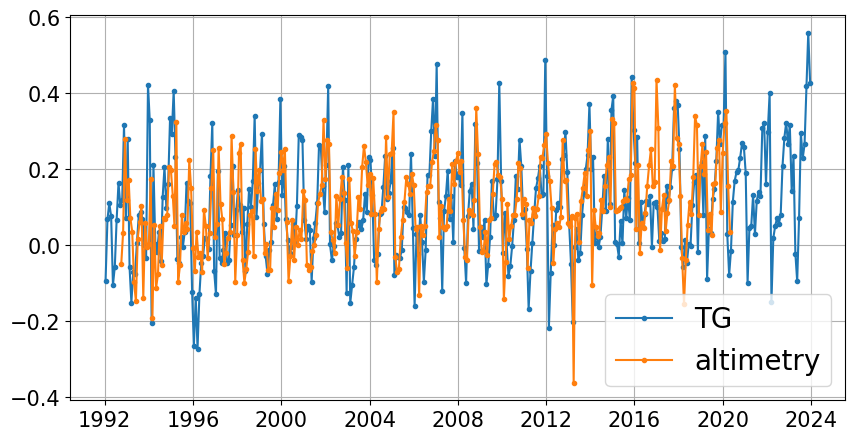

In [19]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(tg_psmsl.index, tg_debias, '.-', label='TG')
ax.plot(combined.index, combined.values, '.-', label='altimetry')
ax.grid()
ax.legend()

In [24]:
tg_at_alt_time = CD_altimetry.interpolate_tg_to_alt(combined.index, tg_debias.index, tg_debias)

corr, p = stats.pearsonr(combined, tg_at_alt_time)
print(f'corr: {round(corr,4)}, p-value: {p}')

rmse = CD_altimetry.compute_RMSE(combined, tg_at_alt_time)
print(f'RMSE: {rmse}')

x = CD_helper_functions.datetime_to_decimal_numbers(tg_at_alt_time.index)
trend_tg = CD_statistics.compute_trend(x, tg_at_alt_time)
print(f'Trend from tide gauge: {trend_tg*1000} mm/year')

x = CD_helper_functions.datetime_to_decimal_numbers(combined.index)
trend_alt = CD_statistics.compute_trend(x, combined)
print(f'Trend from altimetry: {trend_alt*1000} mm/year')

corr: 0.6144, p-value: 7.768058689073966e-36
RMSE: 0.10274703392879907
Trend from tide gauge: 2.7 mm/year
Trend from altimetry: 4.5 mm/year
